# California Housing Price Prediction

Predict median house value for California districts using the 1990 census data.  
Target variable: `median_house_value` (continuous — regression problem)

**Pipeline**
1. Data Loading & Inspection
2. Exploratory Data Analysis
3. Data Cleaning
4. Feature Engineering
5. Preprocessing
6. Model Training & Evaluation
7. Hyperparameter Optimization
8. Final Evaluation & Feature Importance

## 1. Data Loading & Inspection

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

SEED = 42

In [3]:
df = pd.read_csv('data/housing.csv')

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
print(f'\nMissing values:')
print(df.isnull().sum())


Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


**Notes from inspection**
- `total_bedrooms` has 207 missing values — will impute with median.
- `median_house_value` is capped at 500,001. These 965 rows are price-censored; we keep them but note the ceiling effect.
- `ocean_proximity` is categorical with 5 levels.

## 2. Exploratory Data Analysis

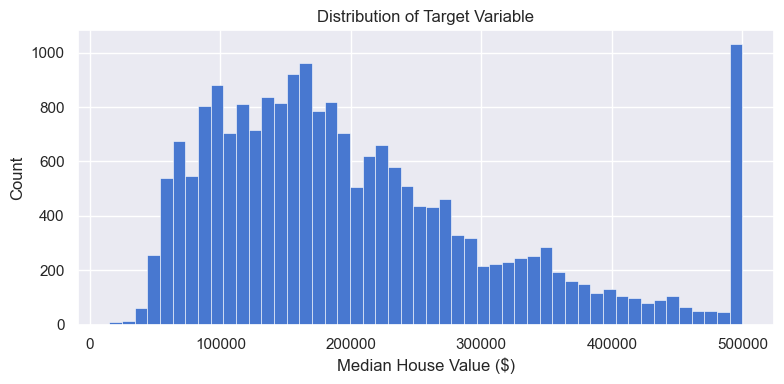

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['median_house_value'], bins=50, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Median House Value ($)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Target Variable')
plt.tight_layout()
plt.show()

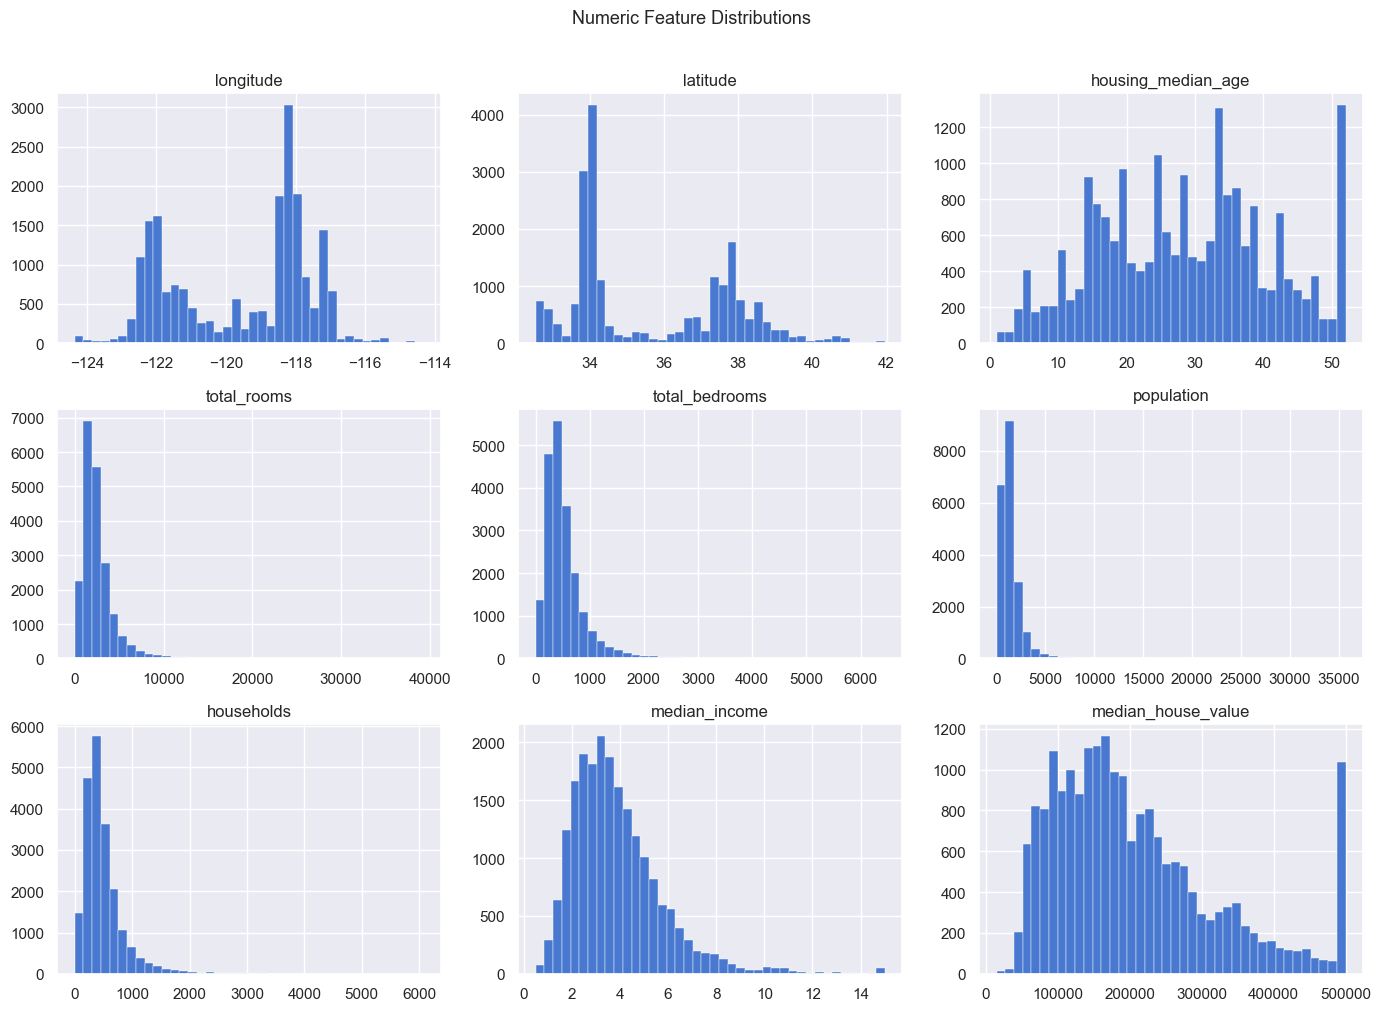

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(df[col].dropna(), bins=40, edgecolor='white', linewidth=0.3)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Numeric Feature Distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

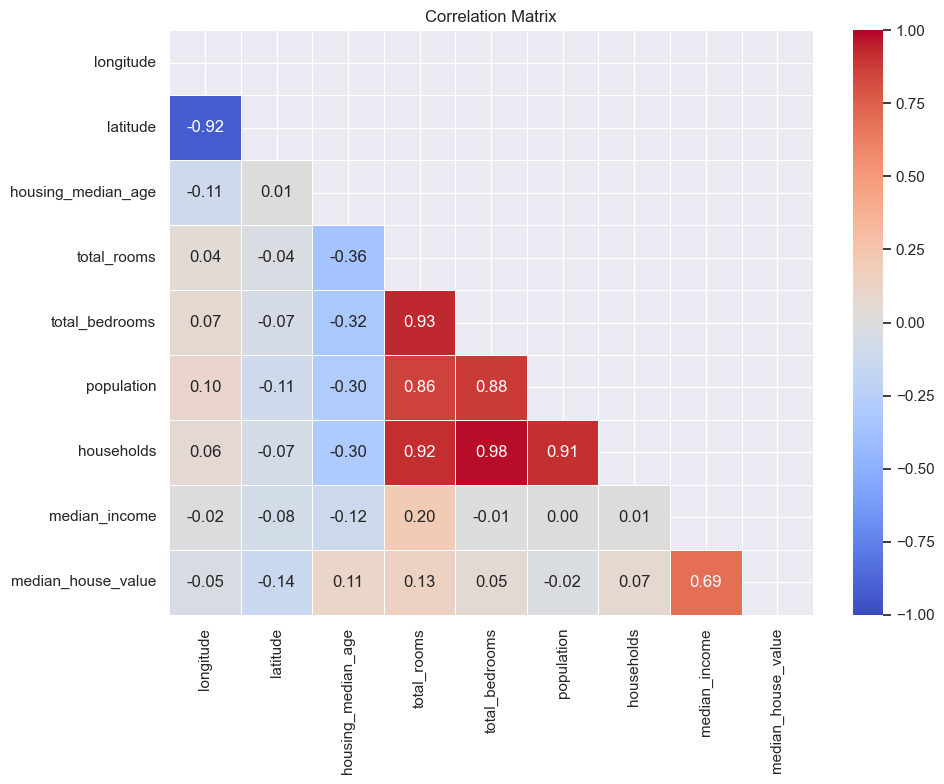

In [9]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

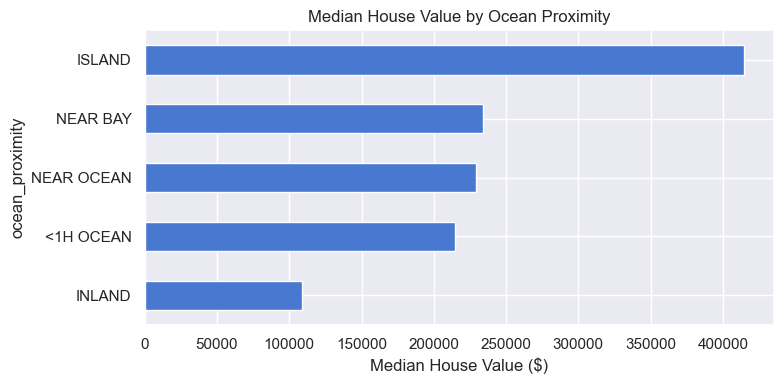

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
df.groupby('ocean_proximity')['median_house_value'].median().sort_values().plot(
    kind='barh', ax=ax
)
ax.set_xlabel('Median House Value ($)')
ax.set_title('Median House Value by Ocean Proximity')
plt.tight_layout()
plt.show()

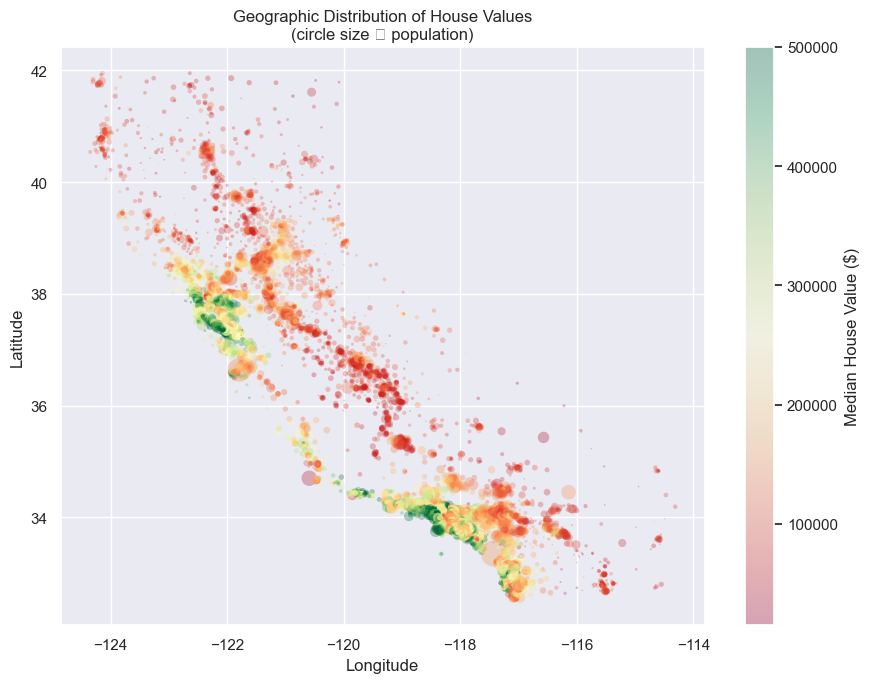

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    df['longitude'], df['latitude'],
    c=df['median_house_value'], cmap='RdYlGn',
    alpha=0.3, s=df['population'] / 100, linewidths=0
)
plt.colorbar(sc, ax=ax, label='Median House Value ($)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Distribution of House Values\n(circle size ∝ population)')
plt.tight_layout()
plt.show()

## 3. Data Cleaning

In [12]:
# Remove capped target rows — these are censored observations that
# distort regression toward the ceiling and hurt generalization.
df = df[df['median_house_value'] < 500001].copy()
print(f'Rows after removing capped target: {len(df)}')

Rows after removing capped target: 19675


## 4. Feature Engineering

In [13]:
# Raw room/bedroom counts are per-district totals and correlate with
# population size rather than housing quality. Per-household ratios
# are far more informative.

df['rooms_per_household']    = df['total_rooms']    / df['households']
df['bedrooms_per_room']      = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']   / df['households']

print('New features added:')
print(df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe())

New features added:
       rooms_per_household  bedrooms_per_room  population_per_household
count         19675.000000       19475.000000              19675.000000
mean              5.360901           0.214975                  3.095189
std               2.292538           0.056937                 10.631977
min               0.846154           0.100000                  0.692308
25%               4.414568           0.177655                  2.445486
50%               5.184322           0.204583                  2.837134
75%               5.970677           0.240950                  3.304894
max             132.533333           1.000000               1243.333333


## 5. Preprocessing

In [14]:
TARGET = 'median_house_value'

# Drop raw totals — replaced by ratios above.
DROP_COLS = ['total_rooms', 'total_bedrooms', 'population', 'households']

X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]

NUMERIC_FEATURES = X.select_dtypes(include=np.number).columns.tolist()
CATEGORICAL_FEATURES = X.select_dtypes(include='object').columns.tolist()

print('Numeric features :', NUMERIC_FEATURES)
print('Categorical features:', CATEGORICAL_FEATURES)

Numeric features : ['longitude', 'latitude', 'housing_median_age', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
Categorical features: ['ocean_proximity']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (15740, 8)  |  Test: (3935, 8)


In [16]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,  NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

## 6. Model Training & Evaluation

In [17]:
import numpy as np

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    
    mae = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2 = r2_score(y_te, preds)
    
    # Cross‑validation: use neg_mean_squared_error, then take sqrt
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5,
                                scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cv_scores)          # convert negative MSE to RMSE
    cv_mean = cv_rmse.mean()
    cv_std = cv_rmse.std()
    
    print(f'{name}')
    print(f'  MAE  : ${mae:,.0f}')
    print(f'  RMSE : ${rmse:,.0f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  CV RMSE (5-fold): ${cv_mean:,.0f} ± ${cv_std:,.0f}')
    print()
    
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_RMSE_mean': cv_mean}

In [18]:
models = {
    'Linear Regression'         : LinearRegression(),
    'Ridge Regression'          : Ridge(alpha=10),
    'Random Forest'             : RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient Boosting'         : GradientBoostingRegressor(n_estimators=200, random_state=SEED),
}

results = []
fitted_models = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', estimator)])
    res = evaluate(name, pipe, X_train, y_train, X_test, y_test)
    results.append(res)
    fitted_models[name] = pipe

Linear Regression
  MAE  : $47,286
  RMSE : $63,663
  R²   : 0.5935
  CV RMSE (5-fold): $62,225 ± $975

Ridge Regression
  MAE  : $47,275
  RMSE : $63,645
  R²   : 0.5937
  CV RMSE (5-fold): $62,264 ± $940

Random Forest
  MAE  : $30,465
  RMSE : $45,909
  R²   : 0.7886
  CV RMSE (5-fold): $45,049 ± $466

Gradient Boosting
  MAE  : $32,627
  RMSE : $46,894
  R²   : 0.7795
  CV RMSE (5-fold): $45,718 ± $634



In [19]:
results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

,name,MAE,RMSE,R2,CV_RMSE_mean
2,Random Forest,30464.695957,45909.200826,0.788621,45048.624360
3,Gradient Boosting,32627.179251,46894.219328,0.779453,45718.166359
1,Ridge Regression,47274.755984,63645.396880,0.593748,62264.276062
0,Linear Regression,47286.321053,63662.658699,0.593527,62225.177878


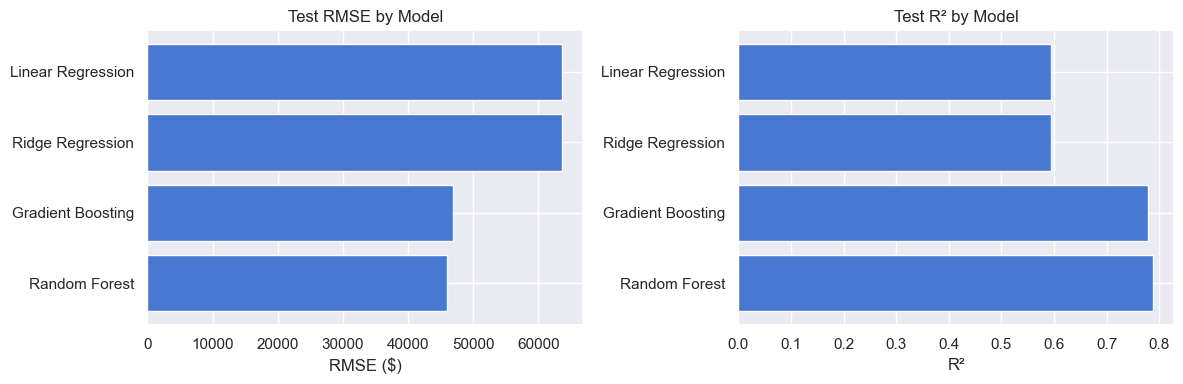

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(results_df['name'], results_df['RMSE'])
axes[0].set_xlabel('RMSE ($)')
axes[0].set_title('Test RMSE by Model')

axes[1].barh(results_df['name'], results_df['R2'])
axes[1].set_xlabel('R²')
axes[1].set_title('Test R² by Model')

plt.tight_layout()
plt.show()

## 7. Hyperparameter Optimization

Gradient Boosting performed best. Tune it with RandomizedSearchCV.

In [21]:
param_dist = {
    'model__n_estimators'      : [100, 200, 300, 400],
    'model__learning_rate'     : [0.01, 0.05, 0.1, 0.15],
    'model__max_depth'         : [3, 4, 5, 6],
    'model__min_samples_split' : [2, 5, 10],
    'model__subsample'         : [0.7, 0.8, 0.9, 1.0],
    'model__max_features'      : ['sqrt', 'log2', None],
}

gb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=SEED))
])

search = RandomizedSearchCV(
    gb_pipe,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
print('\nBest params:', search.best_params_)
print(f'Best CV RMSE: ${-search.best_score_:,.0f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params: {'model__subsample': 0.9, 'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__max_features': 'log2', 'model__max_depth': 6, 'model__learning_rate': 0.1}
Best CV RMSE: $41,654


## 8. Final Evaluation & Feature Importance

In [22]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

final_mae  = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))   # <--- fixed
final_r2   = r2_score(y_test, y_pred)

print('=== Tuned Gradient Boosting — Test Set ===')
print(f'MAE  : ${final_mae:,.0f}')
print(f'RMSE : ${final_rmse:,.0f}')
print(f'R²   : {final_r2:.4f}')

=== Tuned Gradient Boosting — Test Set ===
MAE  : $28,069
RMSE : $42,113
R²   : 0.8221


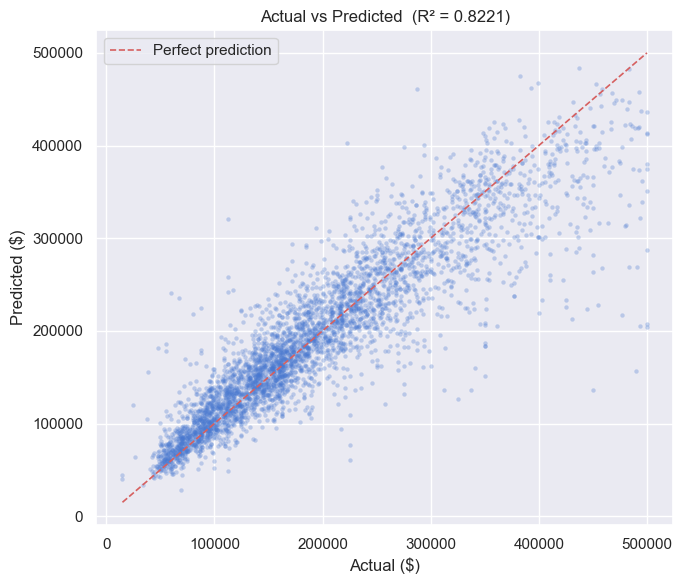

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=10, linewidths=0)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect prediction')
ax.set_xlabel('Actual ($)')
ax.set_ylabel('Predicted ($)')
ax.set_title(f'Actual vs Predicted  (R² = {final_r2:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

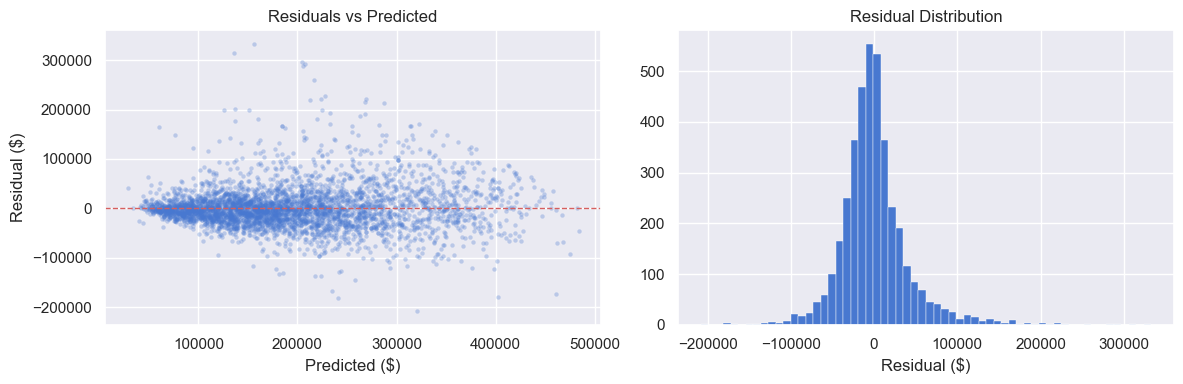

In [24]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, residuals, alpha=0.3, s=10, linewidths=0)
axes[0].axhline(0, color='r', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=60, edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Residual ($)')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

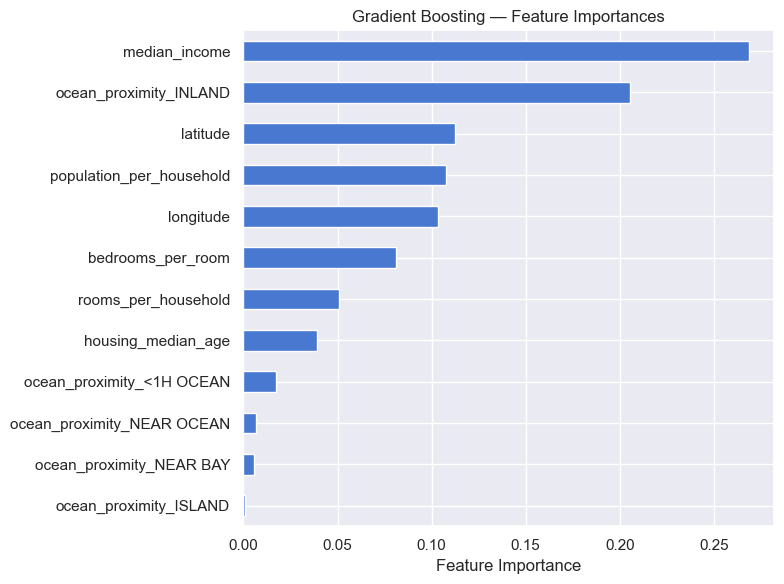

In [25]:
# Extract feature names after preprocessing
ohe_cats = (
    best_model.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
feature_names = NUMERIC_FEATURES + list(ohe_cats)

importances = best_model.named_steps['model'].feature_importances_
feat_df = (
    pd.Series(importances, index=feature_names)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
feat_df.plot(kind='barh', ax=ax)
ax.set_xlabel('Feature Importance')
ax.set_title('Gradient Boosting — Feature Importances')
plt.tight_layout()
plt.show()

In [26]:
print('Top 5 features:')
print(feat_df.sort_values(ascending=False).head())

Top 5 features:
median_income               0.268596
ocean_proximity_INLAND      0.205632
latitude                    0.112599
population_per_household    0.107821
longitude                   0.103663
dtype: float64
